# **LABELING DATA AVETA HOTEL MALIOBORO**




Library

In [2]:
# ! pip install transformers torch pandas openpyxl

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from transformers import pipeline

In [4]:
# file: preprocessing
data = pd.read_csv(
    "/content/drive/MyDrive/Note TA (Tugas Akhir)/analisis_sentimen/data_aveta_tr.csv",
    encoding="latin1",
    engine="python"
)

# jika kolom masih tergabung
if "rating,ulasan" in data.columns:
    data[['rating', 'ulasan']] = data['rating,ulasan'].str.split(',', n=1, expand=True)
    data = data.drop(columns=['rating,ulasan'])

# hapus kolom unnamed
data = data.loc[:, ~data.columns.str.contains("^Unnamed")]

print("Total data:", len(data))
print(data.head())

Total data: 2449
  rating                                             ulasan
0    5/5  Hotel yang sangat strategis di Jalan Malioboro...
1    5/5  Lokasi teratas. Di sekitar lokasi hotel banyak...
2    2/5  Saya tidak cukup merekomendasikannya. Memesan ...
3    5/5  Menginap 2 hari 2 malam bersama istri dan anak...
4    2/5  Saya memberikan ini 2 bintang sebelum saya mem...


**Transformer Lbeling**

In [6]:
#Inisialisasi Model Transformer
sentiment_analyzer = pipeline(
    "sentiment-analysis",
    model="w11wo/indonesian-roberta-base-sentiment-classifier",
    truncation=True,
    max_length=512,
    framework="pt")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: w11wo/indonesian-roberta-base-sentiment-classifier
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/328 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

In [7]:
# Jalankan analisis untuk setiap teks
def get_label_result(text):
    if pd.isna(text):
        return np.nan
    try:
        result = sentiment_analyzer(
            text,
            truncation=True,
            max_length=512)[0]
        label = result["label"].upper()
        if label == "POSITIVE":
            return 1
        elif label == "NEGATIVE":
            return 0
        else:
            return np.nan
    except Exception as e:
        return np.nan
# Terapkan ke kolom 'Ulasan'
data['label'] = data['ulasan'].apply(get_label_result)

In [8]:
# Hitung distribusi hasil labeling
hasil_label = data['label'].value_counts(dropna=False)
print("Statistik Labeling")
print(f"Total data       : {len(data)}")
print(f"Positif (1)      : {hasil_label.get(1, 0)}")
print(f"Negatif (0)      : {hasil_label.get(0, 0)}")
print(f"Belum terlabeli  : {hasil_label.get(np.nan, 0)}")
print("\n Persentase")
print((hasil_label / len(data) * 100).round(2))

Statistik Labeling
Total data       : 2449
Positif (1)      : 2152
Negatif (0)      : 250
Belum terlabeli  : 47

 Persentase
label
1.0    87.87
0.0    10.21
NaN     1.92
Name: count, dtype: float64


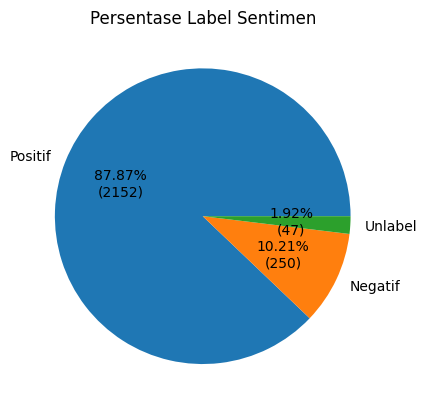

In [9]:
# ambil jumlah label
positif = hasil_label.get(1, 0)
negatif = hasil_label.get(0, 0)
belum = data['label'].isna().sum()
labels = ['Positif', 'Negatif', 'Unlabel']
values = [positif, negatif, belum]
total = sum(values)
def autopct_format(pct):
    count = int(round(pct * total / 100.0))
    return f'{pct:.2f}%\n({count})'
plt.figure()
plt.pie(values, labels=labels, autopct=autopct_format)
plt.title("Persentase Label Sentimen")
plt.show()

In [10]:
data

,rating,ulasan,label
0,5/5,Hotel yang sangat strategis di Jalan Malioboro...,0.0
1,5/5,Lokasi teratas. Di sekitar lokasi hotel banyak...,1.0
2,2/5,Saya tidak cukup merekomendasikannya. Memesan ...,0.0
3,5/5,Menginap 2 hari 2 malam bersama istri dan anak...,1.0
4,2/5,Saya memberikan ini 2 bintang sebelum saya mem...,0.0
...,...,...,...
2444,5/5,Semoga beruntung ????,0.0
2445,4/5,Layanan ??????,0.0
2446,1/5,Limbah..,0.0
2447,5/5,Malioboro area,NaN


In [11]:
def label(label):
    if label == 1:
        return "Positif"
    elif label == 0:
        return "Negatif"
    else:
        return None
data["label"] = data["label"].apply(label)

In [12]:
data

,rating,ulasan,label
0,5/5,Hotel yang sangat strategis di Jalan Malioboro...,Negatif
1,5/5,Lokasi teratas. Di sekitar lokasi hotel banyak...,Positif
2,2/5,Saya tidak cukup merekomendasikannya. Memesan ...,Negatif
3,5/5,Menginap 2 hari 2 malam bersama istri dan anak...,Positif
4,2/5,Saya memberikan ini 2 bintang sebelum saya mem...,Negatif
...,...,...,...
2444,5/5,Semoga beruntung ????,Negatif
2445,4/5,Layanan ??????,Negatif
2446,1/5,Limbah..,Negatif
2447,5/5,Malioboro area,None


**Negatif**

In [13]:
df_negatif = data[data['label'] == "Negatif"]
print(df_negatif)

     rating                                             ulasan    label
0       5/5  Hotel yang sangat strategis di Jalan Malioboro...  Negatif
2       2/5  Saya tidak cukup merekomendasikannya. Memesan ...  Negatif
4       2/5  Saya memberikan ini 2 bintang sebelum saya mem...  Negatif
6       1/5  Pengalaman menginap yang tidak menyenangkan..?...  Negatif
22      1/5  Listrik padam sampai 20 menit, tidak ada penje...  Negatif
...     ...                                                ...      ...
2443    5/5                                   Direkomendasikan  Negatif
2444    5/5                              Semoga beruntung ????  Negatif
2445    4/5                                     Layanan ??????  Negatif
2446    1/5                                           Limbah..  Negatif
2448    3/5                                          Itu besar  Negatif

[250 rows x 3 columns]


In [15]:
for idx, ulasan in df_negatif['ulasan'].items():
    print(f"{idx}: {ulasan}")
    print('-' * 50)#negatif

0: Hotel yang sangat strategis di Jalan Malioboro. Karyawan yang ramah. Kamar bersih. Housekeepingnya juga bagus, bersih dan bekerja dengan cepat. Minus : 1. Tidak ada tempat parkir. Sangat terbatas, harus valet, yang dibutuhkan hanya kunci. Membuatnya tidak nyaman.2. Kamar mandinya tidak dilengkapi hand shower. Kalau bawa bayi susah mandinya karena showernya hanya ada di atap. Untuk sarapannya variasinya cukup enak, tapi rasanya sangat kurang. Menurutku itu tidak bagus. Hehehe. Seharusnya lebih baik. Semoga dapat ditingkatkan4. Ruangannya tidak kedap udara. Apalagi jika tarikan kursi dari kamar sebelah sangat jelas. Semoga ada perbaikan. Hotel ini sangat direkomendasikan untuk dicoba. Semoga pelayanan dan kebersihannya tetap terjaga sama atau bahkan lebih baik lagi.
--------------------------------------------------
2: Saya tidak cukup merekomendasikannya. Memesan kamar premier di link Aveta Hotel, tidak mendapat BF. Meskipun ketika kami check in, kami diberitahu bahwa kami memiliki b

Unlabeled

In [16]:
df_unlabeled = data[data['label'].isna()]
print(df_unlabeled)

     rating                                             ulasan label
133     5/5  Rombongan tamu yang menggunakan Hiace Premio L...  None
204     5/5                           Seperti desain minimalis  None
602     5/5  Minimal 1, bagi perokok disarankan cari hotel ...  None
1258    3/5  Akses kendaraan menuju hotel menjadi kendala k...  None
1499    5/5  Firdaus, Isa, Aulia, Yuni thank you for your s...  None
1573    5/5  Tersedia becak sepeda motor di depan hotel unt...  None
1588    5/5  Mas Firdausmba Raramba Via Terima kasih atas p...  None
1751    5/5            Firdaus, Kak Silvi, Pak Novel Staf, oke  None
1766    5/5  Terima kasih.. Apakah kamarnya membuat tidur a...  None
1772    5/5  Menjadi hotel berlangganan jika berlibur ke Jogja  None
1773    5/5  Telah dibuka akses jalan kecil di samping Mali...  None
1842    5/5                                          Tidak ada  None
1889    5/5   Keluar dari pintu hotel langsung di Jl Malioboro  None
1896    4/5   Very strategic posit

In [17]:
for idx, ulasan in df_unlabeled['ulasan'].items():
    print(f"{idx}: {ulasan}")
    print('-' * 50) #unlabeled

133: Rombongan tamu yang menggunakan Hiace Premio Luxury 8 kursi menginap di Aveta Hotel Malioboro
--------------------------------------------------
204: Seperti desain minimalis
--------------------------------------------------
602: Minimal 1, bagi perokok disarankan cari hotel lain hehehehe
--------------------------------------------------
1258: Akses kendaraan menuju hotel menjadi kendala kelancaran operasional saat Jalan Malioboro ditutup mulai tanggal 18-21...
--------------------------------------------------
1499: Firdaus, Isa, Aulia, Yuni thank you for your service
--------------------------------------------------
1573: Tersedia becak sepeda motor di depan hotel untuk berkeliling Malioboro
--------------------------------------------------
1588: Mas Firdausmba Raramba Via Terima kasih atas pelayanan primanya
--------------------------------------------------
1751: Firdaus, Kak Silvi, Pak Novel Staf, oke
--------------------------------------------------
1766: Terima kasih..

In [ ]:
# data = data.drop(columns=["label tranformer"])

In [18]:
# # Simpan Hasil ke File
# data.to_csv("hasil_labeling_aveta_transformer_tr.csv")